# Experimento 06 (baseline/Ju+Si)

Investigar a existência de agrupamentos naturais nos dados biomecânicos da marcha do subconjunto Ju e Si utilizando K-Means sem redução dimensional.

# 1. Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from google.colab import drive

# 2. Montando o Google Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3. Carregando o Dataset Baseline

In [3]:
BASE_PATH = Path('/content/drive/MyDrive/results')

ju_file = BASE_PATH / 'ju_baseline_features.csv'
si_file = BASE_PATH / 'si_baseline_features.csv'

ju_df = pd.read_csv(ju_file)
si_df = pd.read_csv(si_file)

In [4]:
combined_df = pd.concat(
    [ju_df, si_df],
    ignore_index=True
)

In [5]:
combined_df.shape

(193, 12)

In [6]:
combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
0,Ju,JuCo06_01,491.034501,458.574755,408.370356,387.052169,0.831653,0.844033,32.459747,32.459747,1003.64,1011.23
1,Ju,JuPt28_04,463.802448,441.058882,402.657635,390.279068,0.868166,0.884868,22.743566,22.743566,1014.09,1015.41
2,Ju,JuPt28_05,461.044277,439.617162,404.446082,392.266889,0.877239,0.892292,21.427115,21.427115,1018.93,1013.32
3,Ju,JuCo19_01,397.458941,384.621782,351.571417,335.652774,0.884548,0.872683,12.837160,12.837160,944.13,906.73
4,Ju,JuPt03_05,447.612376,449.400087,376.883198,395.509597,0.841986,0.880083,-1.787712,1.787712,1045.11,1016.07


In [7]:
combined_df.info()
combined_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          193 non-null    object 
 1   patient_id       193 non-null    object 
 2   mean_total_L     193 non-null    float64
 3   mean_total_R     193 non-null    float64
 4   std_total_L      193 non-null    float64
 5   std_total_R      193 non-null    float64
 6   cv_total_L       193 non-null    float64
 7   cv_total_R       193 non-null    float64
 8   assimetria_mean  193 non-null    float64
 9   assimetria_abs   193 non-null    float64
 10  peak_force_L     193 non-null    float64
 11  peak_force_R     193 non-null    float64
dtypes: float64(10), object(2)
memory usage: 18.2+ KB


,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,455.209696,457.041114,394.664923,395.336352,0.868050,0.865807,-1.831418,26.658448,1086.407306,1075.179896
std,69.729512,66.169195,59.084324,56.596120,0.029783,0.028170,35.940566,24.098164,173.530063,170.033100
min,297.722340,280.285646,253.381604,251.828916,0.787837,0.783832,-104.968020,0.291942,679.360000,662.200000
25%,411.730834,419.042495,356.771428,361.588039,0.845163,0.849707,-18.877668,9.325455,988.240000,971.740000
50%,463.546360,460.883054,396.413635,395.206976,0.868543,0.867767,1.343636,19.289730,1059.080000,1042.360000
75%,493.580845,502.458180,434.638476,438.272270,0.890118,0.883850,19.791320,37.199714,1208.680000,1195.370000
max,687.630032,702.366501,612.168131,634.996815,0.938781,0.929556,86.617580,104.968020,1816.540000,1911.030000


# 4. Defininção das features

Removendo colunas não utilizadas no clustering

In [8]:
feature_cols = [
    'mean_total_L',
    'mean_total_R',

    'std_total_L',
    'std_total_R',

    'cv_total_L',
    'cv_total_R',

    'assimetria_mean',
    'assimetria_abs',

    'peak_force_L',
    'peak_force_R'
]

X = combined_df[feature_cols]

# 5. Normalização dos dados

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Escolha do número de clusters

## Elbow Method

In [10]:
inertia = []

k_values = range(2, 7)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Visualizando o Elbow Method

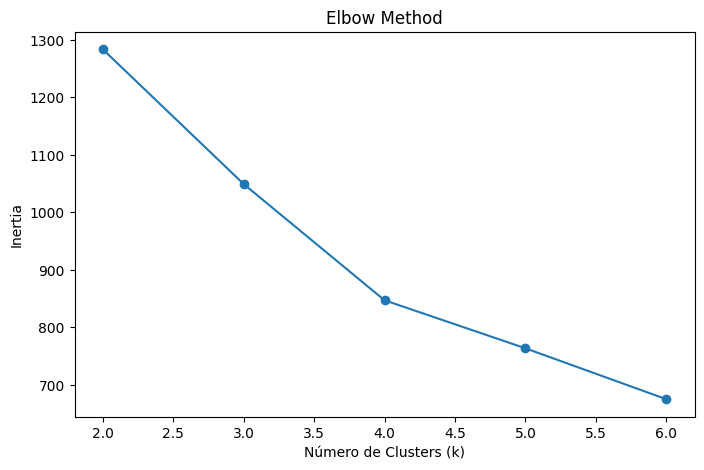

In [11]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')

plt.show()

# 7. Avaliação com Silhouette Score

In [12]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f'k={k} | Silhouette Score: {score:.4f}')

k=2 | Silhouette Score: 0.2926
k=3 | Silhouette Score: 0.2403
k=4 | Silhouette Score: 0.2869
k=5 | Silhouette Score: 0.2360
k=6 | Silhouette Score: 0.2833


Vizualização com o Silhouette Score

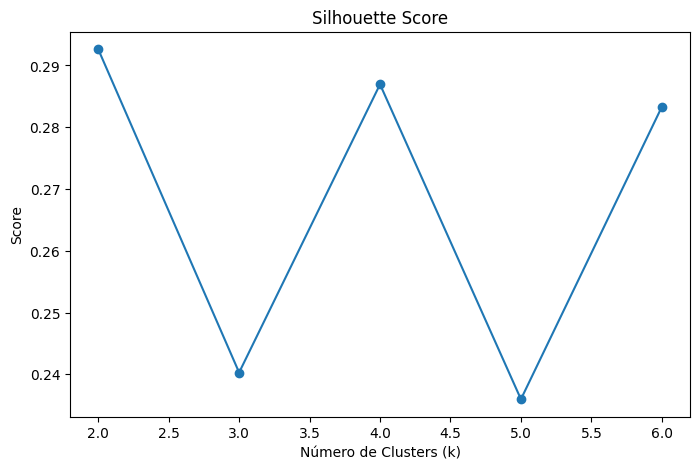

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')

plt.show()

# 8. Treinamento final com o K-Means

In [14]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

Adicionando clusters ao dataframe

In [15]:
combined_df['cluster'] = clusters

combined_df.head()

,dataset,patient_id,mean_total_L,mean_total_R,std_total_L,std_total_R,cv_total_L,cv_total_R,assimetria_mean,assimetria_abs,peak_force_L,peak_force_R,cluster
0,Ju,JuCo06_01,491.034501,458.574755,408.370356,387.052169,0.831653,0.844033,32.459747,32.459747,1003.64,1011.23,1
1,Ju,JuPt28_04,463.802448,441.058882,402.657635,390.279068,0.868166,0.884868,22.743566,22.743566,1014.09,1015.41,1
2,Ju,JuPt28_05,461.044277,439.617162,404.446082,392.266889,0.877239,0.892292,21.427115,21.427115,1018.93,1013.32,1
3,Ju,JuCo19_01,397.458941,384.621782,351.571417,335.652774,0.884548,0.872683,12.837160,12.837160,944.13,906.73,1
4,Ju,JuPt03_05,447.612376,449.400087,376.883198,395.509597,0.841986,0.880083,-1.787712,1.787712,1045.11,1016.07,1


# 9. Métricas Internas

In [16]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)

print(f'Silhouette Score: {silhouette:.4f}')
print(f'Davies-Bouldin Index: {davies:.4f}')
print(f'Calinski-Harabasz Score: {calinski:.4f}')

Silhouette Score: 0.2926
Davies-Bouldin Index: 1.2945
Calinski-Harabasz Score: 96.2614


# 10. Visualização dos Clusters

PCA somente usado para visualização

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

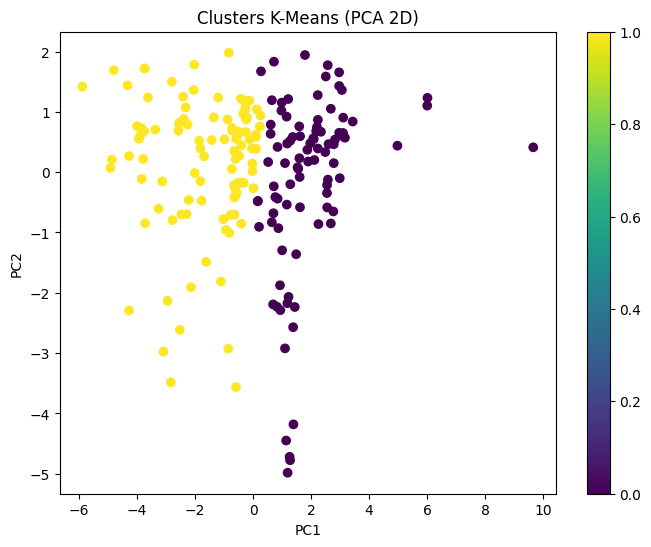

In [18]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters K-Means (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

# 11. HeatMap dos centroídes

In [19]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)

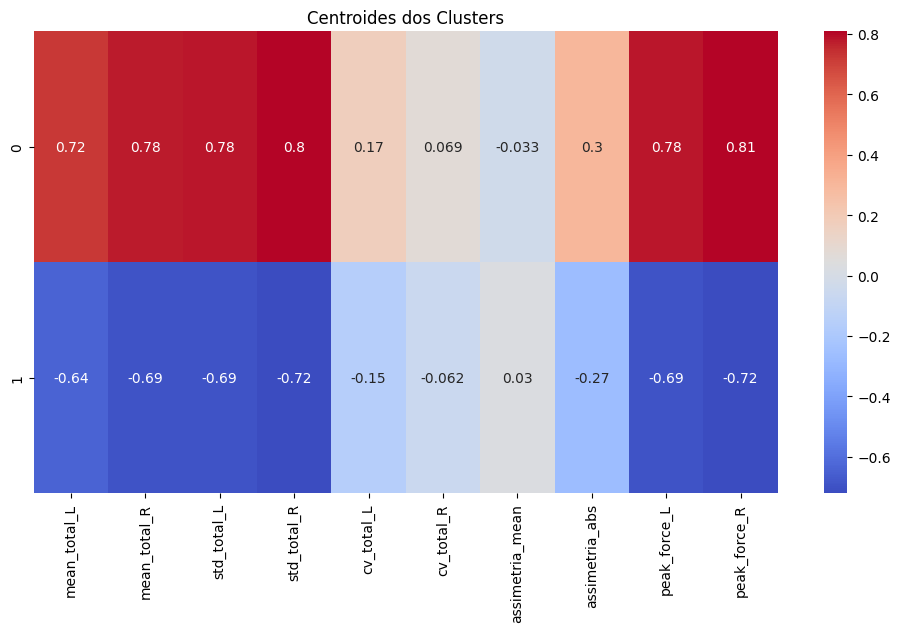

In [20]:
plt.figure(figsize=(12,6))

sns.heatmap(
    centroids,
    annot=True,
    cmap='coolwarm'
)

plt.title('Centroides dos Clusters')

plt.show()

# 12. Distribuição dos Clusters

In [21]:
combined_df['cluster'].value_counts()

,count
cluster,
1,102
0,91


# 13. Composição dos clusters por dataset

In [22]:
combined_df.groupby('cluster')['dataset'].value_counts()

cluster  dataset
0        Ju         56
         Si         35
1        Ju         73
         Si         29
Name: count, dtype: int64

# 14. Média das features por cluster e dataset

In [23]:
combined_df.groupby(
    ['cluster', 'dataset']
)[feature_cols].mean()

mean_total_L  mean_total_R  std_total_L  std_total_R  \
cluster dataset                                                         
0       Ju         509.362932    513.932009   442.800699   445.157009   
        Si         498.530633    499.066979   436.940439   433.508564   
1       Ju         413.388515    413.628435   355.130031   356.731743   
        Si         403.628045    405.742152   350.209770   350.238152   

                 cv_total_L  cv_total_R  assimetria_mean  assimetria_abs  \
cluster dataset                                                            
0       Ju         0.870902    0.867045        -4.569077       39.586996   
        Si         0.876892    0.868867        -0.536345       24.856180   
1       Ju         0.861091    0.863770        -0.239920       18.599354   
        Si         0.869387    0.864850        -2.114107       24.154814   

                 peak_force_L  peak_force_R  
cluster dataset                              
0       Ju        1221.872143   1213.358929  
        Si        1220.113714   1210.462000  
1       Ju         973.626575    956.416849  
        Si         947.346552    944.035172